# The 4x3 Grid World: From MDPs to Reinforcement Learning

- This notebook teaches sequential decision making through the canonical AIMA
  4x3 grid world, built entirely from scratch with `numpy` (no `gymnasium`)
- The grid world is the unifying example throughout:
  - It appears in the MDP definition, utility of states, Bellman equations,
    value iteration, policy iteration, and Q-learning
- The pedagogical arc is:
  - Build the environment (states, stochastic transitions, rewards)
  - Solve it with full knowledge (value iteration, policy iteration)
  - Learn it without knowing the model (Q-learning)

## Imports

In [58]:
%load_ext autoreload
%autoreload 2

# System libraries.
import logging

# Third-party libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style.
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
import helpers.hnotebook as hnotebook

import L12_01_gridworld_4x3_utils as utils

# Initialize notebook configuration and logging.
hnotebook.config_notebook()
_LOG = logging.getLogger(__name__)
utils.init_loggers(_LOG)

# Part 1: Building the Grid World Environment

## Cell 1.1: The 4x3 Grid and Its States

**Goal**:
- Visualize the grid world layout that every later algorithm will reason about
- Identify the special cells: start, terminals, and wall
- This is the world the agent lives in
- It is fully observable (the agent always knows its cell) but stochastic
  (actions do not always succeed)
- Cell `(1, 1)` is `START`, cell `(4, 3)` is the `+1` terminal (green), cell
  `(4, 2)` is the `-1` terminal (red), cell `(2, 2)` is a wall (grey)

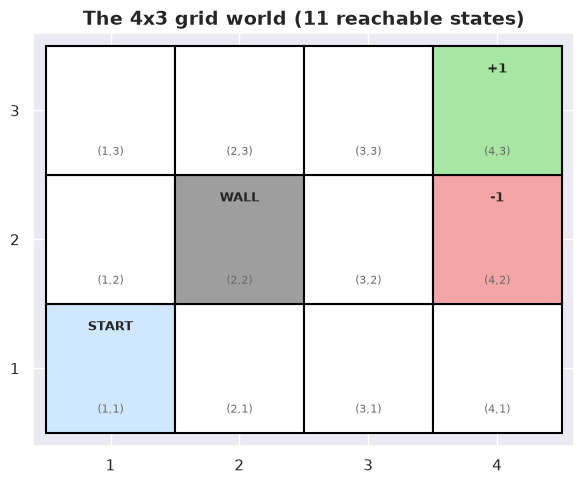

env.states (n=11): [(1, 1), (2, 1), (3, 1), (4, 1), (1, 2), (3, 2), (4, 2), (1, 3), (2, 3), (3, 3), (4, 3)]
env.terminals= {(4, 3): 1.0, (4, 2): -1.0}
env.walls= {(2, 2)}


In [60]:
# Draw the grid layout that every later algorithm will reason about.
utils.cell1_1_show_grid()

**Key observations**:
- The environment has 11 reachable states (12 cells minus 1 wall)
- Two states are terminal: reaching either ends the episode

## Cell 1.2: Stochastic Action Model

**Goal**:
- Show why this is an MDP and not a deterministic puzzle
- The unreliable actions are the entire source of difficulty

In [61]:
# Create interactive widget showing the stochastic action model.
utils.cell1_2_stochastic_action()

**Key observations**:
- With $\Pr(\text{intended}) = 0.8$, the agent goes sideways $20\%$ of the time
- Walls and boundaries bounce the agent back to its current cell
- As `p_intended` approaches $1.0$, the world becomes deterministic
- The intended direction carries probability `p_intended`
- The two perpendicular directions split the remaining mass equally
- A blocked move (wall or boundary) returns the agent to its current cell

## Cell 1.3: Transition Model as an Explicit Table

**Goal**:
- Make the abstract $\Pr(s' \mid s, a)$ concrete as an actual probability table

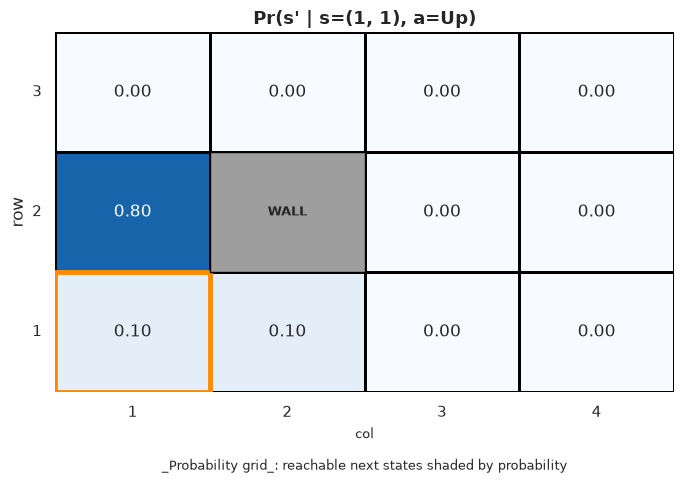

,state s,action a,next state s',"Pr(s' | s, a)"
0,"(1, 1)",Up,"(1, 2)",0.8
1,"(1, 1)",Up,"(1, 1)",0.1
2,"(1, 1)",Up,"(2, 1)",0.1


In [62]:
# Display the concrete Pr(s' | s, a) table for the START state and Up action.
utils.cell1_3_show_transition_table()

In [63]:
# Show the transition model row for a chosen state and action pair.
utils.cell1_3_transition_table()

**Key observations**:
- The transition model has shape $|S| \times |A| \times |S|$, but is sparse
- Each $(s, a)$ row sums to $1.0$: it is a probability distribution
- Most next states have zero probability
- This explicit model is exactly what model-free learning will do without

## Cell 1.4: Rewards and Episode Returns

**Goal**:
- Define the reward structure and connect per-step rewards to discounted return
- Show how a single trajectory accumulates $\sum_t \gamma^t R_t$

In [64]:
# Show per-cell rewards and the discounted return of a sample trajectory.
utils.cell1_4_rewards_and_returns()

**Key observations**:
- The small negative living reward $-0.04$ pushes the agent to finish quickly
- The discount factor $\gamma$ weights near-term rewards more than distant ones
- Total return depends on the whole sequence of states, not just the final cell
- Each non-terminal step costs a little, so wandering is penalized
- Lowering gamma shrinks the contribution of later rewards
- The same path yields different returns as the reward and discount change

# Part 2: Solving the MDP with Value Iteration

## Cell 2.1: The Bellman Equation for One State

**Goal**:
- Build intuition for the Bellman update on a single state
- The full algorithm is just this update applied everywhere

In [65]:
# Show the value of each action at one state under converged utilities.
utils.cell2_1_bellman_one_state()

**Key observations**:
- The utility of a state is the value of its best action, not an average
- Each action blends immediate reward with the discounted utility of next states
- The $\max$ operator makes the system nonlinear, so we iterate
- Different actions can have very different values at the same state
- The greedy action is the one whose expected next-state utility is highest
- Repeating this max update everywhere is exactly value iteration

## Cell 2.2: Value Iteration Converging Over Sweeps

**Goal**:
- Watch state utilities converge to a fixed point as we sweep the grid
- See value information propagate backward from the terminals

In [66]:
# Step through value iteration sweeps and watch utilities converge.
utils.cell2_2_value_iteration()

**Key observations**:
- Utility spreads backward from the terminals, one ring of cells per sweep
- Cells near the $+1$ terminal end high
- Cells near the $-1$ terminal end low
- The change per sweep shrinks geometrically: convergence is guaranteed
- Early sweeps only affect cells adjacent to the terminals
- Later sweeps refine the interior until nothing changes
- Higher gamma propagates value further but converges more slowly

## Cell 2.3: Extracting the Optimal Policy

**Goal**:
- Turn converged utilities into an actionable policy
- Take the greedy action in every cell

In [67]:
# Show the greedy policy extracted from converged utilities.
utils.cell2_3_extract_policy()

**Key observations**:
- The policy is derived from utilities, not learned separately
- A large negative living reward makes the agent take the short risky path
- A near-zero living reward makes the agent take the long safe path
- The arrows point toward the action that maximizes expected return
- Near the $-1$ terminal the policy steers cautiously when steps are cheap
- Making each step expensive flips the policy toward the shorter risky route

# Part 3: Solving the MDP with Policy Iteration

## Cell 3.1: Policy Evaluation for a Fixed Policy

**Goal**:
- Compute the utility of a fixed (possibly bad) policy
- This is a simpler linear problem than the full Bellman equation

In [68]:
# Evaluate a fixed policy by solving the linear Bellman system.
utils.cell3_1_policy_evaluation()

**Key observations**:
- With a fixed action per state the $\max$ disappears: the equations are linear
- A bad policy yields low utilities, especially where it steers into $-1$
- Evaluation answers "how good is this policy", not "what should I do instead"
- The linear system $(I - \gamma P) U = b$ is solved directly with `numpy`
- A poor policy produces visibly low utilities near the $-1$ terminal
- Evaluation is the first half of policy iteration

## Cell 3.2: Policy Improvement and Iteration to Optimality

**Goal**:
- Alternate evaluation and improvement until the policy stops changing
- Watch convergence to the optimal policy in a few iterations

In [69]:
# Step through policy iteration rounds and watch arrows flip to optimal.
utils.cell3_2_policy_iteration()

**Key observations**:
- Each round evaluates the policy, then makes it greedy with respect to it
- It converges in very few iterations, often fewer than value iteration sweeps
- It terminates exactly when no state changes its action
- Early rounds flip many arrows at once
- The count of changed states drops to zero at convergence
- A stable policy is provably optimal

## Cell 3.3: Value Iteration vs Policy Iteration

**Goal**:
- Contrast the two exact methods and their convergence behavior
- Understand the tradeoff between many cheap sweeps and few expensive rounds

In [70]:
# Compare convergence of value iteration and policy iteration.
utils.cell3_3_compare_solvers()

**Key observations**:
- Value iteration does many cheap sweeps; policy iteration does few expensive ones
- As $\gamma \to 1$, value iteration needs many more sweeps
- Both converge to the same optimal policy
- Raising gamma stretches the value iteration curve to the right
- Policy iteration stays at a handful of rounds across gamma
- They are different routes to the same answer

# Part 4: Learning Without a Model (Q-Learning)

## Cell 4.1: Why Reinforcement Learning is Harder Than Planning

**Goal**:
- Contrast planning (knowing the model) with learning (discovering through action)
- Understand why the same optimal policy takes a harder route in RL
- Same world, blindfolded: the agent no longer has the transition table
- It must learn the value of actions purely from the rewards it stumbles into
- In RL the agent does not know $\Pr(s' \mid s, a)$ or $R(s, a, s')$
- The agent only sees experience tuples $(s, a, r, s')$ as it moves
- The goal is unchanged (maximize expected return), but it must learn and act
  at the same time

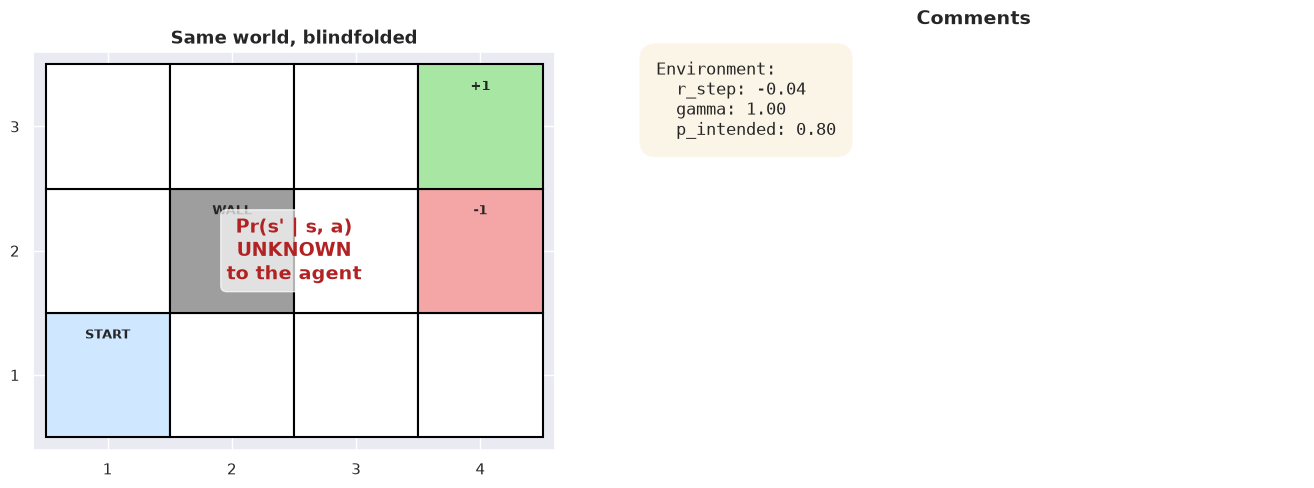

In [71]:
# Contrast planning (knows Pr and R) with learning (must experience transitions).
utils.cell4_1_planning_vs_learning()

**Key observations**:
- Planning reads the model; learning must discover it through action
- Every later algorithm in this part sees only $(s, a, r, s')$ tuples
- The same optimal policy is the target, reached by a harder route

## Cell 4.2: The Q-Learning Update Rule

**Goal**:
- Introduce the single update that powers Q-learning
- Show how one experience tuple nudges a Q-value toward a better estimate

In [72]:
# Show how a single experience tuple nudges a Q-value via the TD update.
utils.cell4_2_q_update_rule()

**Key observations**:
- The TD error $r + \gamma \max_{a'} Q(s', a') - Q(s, a)$ measures surprise
- The learning rate $\alpha$ controls how aggressively we overwrite the estimate
- The update bootstraps from the current estimate of the next state's value
- A larger alpha makes each experience move the estimate further
- The TD target combines the observed reward with the discounted next value
- With alpha near zero the estimate barely moves; near one it jumps to the target

## Cell 4.3: Exploration vs Exploitation with Epsilon-Greedy

**Goal**:
- Show why the agent must sometimes act randomly
- A purely greedy agent can lock onto a suboptimal path

In [73]:
# Compare state coverage under low vs high exploration.
utils.cell4_3_exploration()

**Key observations**:
- A greedy agent may never visit states off its first decent path
- Too much exploration wastes episodes acting randomly
- Effective learning needs a balance, often decaying $\epsilon$ over time
- Low epsilon concentrates visits on a narrow corridor of states
- High epsilon spreads visits broadly but refines actions slowly
- The visit heatmap shows exactly which states the agent has explored

## Cell 4.4: Watching Q-Learning Learn the Optimal Policy

**Goal**:
- Run full Q-learning and watch the learned policy emerge
- Compare it to the policy value iteration found with full knowledge

In [74]:
# Train Q-learning and compare its policy to the value iteration optimum.
utils.cell4_4_q_learning_converges()

**Key observations**:
- With enough episodes, Q-learning recovers the same optimal policy
- The learning curve is noisy early (exploration) and stabilizes as Q converges
- Model-free learning trades sample efficiency for not needing a model
- The learned arrows converge to the value iteration policy as episodes grow
- Returns rise and flatten as the Q-table stops changing
- The same optimal behavior is reached without ever reading the model

# Summary: The Mental Model

- An MDP is defined by states, stochastic actions $\Pr(s' \mid s, a)$, rewards
  $R(s, a, s')$, and a discount $\gamma$; the 4x3 grid makes all four concrete
- When the model is known, value iteration and policy iteration compute the
  optimal policy exactly by solving the Bellman equations
- When the model is unknown, Q-learning learns the optimal policy from raw
  experience tuples $(s, a, r, s')$, balancing exploration and exploitation
- All three methods converge to the same optimal policy on the same world: the
  difference is whether you plan with a model or learn without one